# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("data/processed/churn_clean.csv")

df.head()

,customer_id,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason,age_group,monthly_spend_category,tenure_group,high_value_customer,cltv_segment,churn_risk,payment_mode,internet_category,service_count,engagement_score,customer_status,location,avg_revenue_per_month,coordinates,churn_reason_category,loyalty_level,customer_segment
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,Adult,Medium,0-12 Months,No,Bronze,High,Offline,DSL,3,48.19,Inactive,"Los Angeles, California",54.075000,"(33.964131, -118.272783)",Churned,New,At Risk
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,Adult,High,0-12 Months,No,Bronze,Medium,Online,Fiber,1,32.81,Inactive,"Los Angeles, California",75.825000,"(34.059281, -118.30742)",Churned,New,Standard
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,Adult,High,0-12 Months,Yes,Gold,High,Online,Fiber,5,81.92,Inactive,"Los Angeles, California",102.562500,"(34.048013, -118.293953)",Churned,New,VIP At Risk
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Adult,High,24-48 Months,Yes,Gold,High,Online,Fiber,6,91.23,Inactive,"Los Angeles, California",108.787500,"(34.062125, -118.315709)",Churned,Regular,VIP At Risk
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,Adult,High,48-72 Months,Yes,Gold,High,Online,Fiber,6,103.00,Inactive,"Los Angeles, California",102.781633,"(34.039224, -118.266293)",Churned,Loyal,VIP At Risk


# Dataset Overview

In [5]:
print("Dataset Shape:", df.shape)

print("\n")

print(df.info())

Dataset Shape: (7043, 50)


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             7043 non-null   str    
 1   count                   7043 non-null   int64  
 2   country                 7043 non-null   str    
 3   state                   7043 non-null   str    
 4   city                    7043 non-null   str    
 5   zip_code                7043 non-null   int64  
 6   lat_long                7043 non-null   str    
 7   latitude                7043 non-null   float64
 8   longitude               7043 non-null   float64
 9   gender                  7043 non-null   str    
 10  senior_citizen          7043 non-null   str    
 11  partner                 7043 non-null   str    
 12  dependents              7043 non-null   str    
 13  tenure_months           7043 non-null   int64  
 14  phone_service          

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
lat_long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values Verification

In [7]:
missing = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": (
        df.isnull().sum() /
        len(df)
    ) * 100

})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
loyalty_level,11,0.156183
total_charges,11,0.156183
tenure_group,11,0.156183
avg_revenue_per_month,11,0.156183
city,0,0.000000
zip_code,0,0.000000
country,0,0.000000
state,0,0.000000
longitude,0,0.000000
gender,0,0.000000


# Duplicate Records Verification

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
zip_code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
tenure_months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
monthly_charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
total_charges,7032.0,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000
churn_value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
churn_score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
cltv,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [10]:
statistics = pd.DataFrame({

    "Mean": df[numerical_columns].mean(),

    "Median": df[numerical_columns].median(),

    "Variance": df[numerical_columns].var(),

    "Std Dev": df[numerical_columns].std(),

    "Skewness": df[numerical_columns].apply(skew),

    "Kurtosis": df[numerical_columns].apply(kurtosis)

})

statistics.round(2)

C:\Users\admin\Desktop\New folder\Google_D_A\venv\Lib\site-packages\pandas\core\apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
C:\Users\admin\Desktop\New folder\Google_D_A\venv\Lib\site-packages\pandas\core\apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)


,Mean,Median,Variance,Std Dev,Skewness,Kurtosis
count,1.00,1.00,0.00,0.00,NaN,NaN
zip_code,93521.96,93552.00,3481189.32,1865.79,-0.25,-1.15
latitude,36.28,36.39,6.03,2.46,0.30,-1.14
longitude,-119.80,-119.73,4.66,2.16,-0.04,-1.14
tenure_months,32.37,29.00,603.17,24.56,0.24,-1.39
monthly_charges,64.76,70.35,905.41,30.09,-0.22,-1.26
total_charges,2283.30,1397.48,5138252.41,2266.77,NaN,NaN
churn_value,0.27,0.00,0.19,0.44,1.06,-0.87
churn_score,58.70,61.00,463.33,21.53,-0.09,-1.01
cltv,4400.30,4527.00,1399624.22,1183.06,-0.31,-0.93


## Customer Churn Distribution

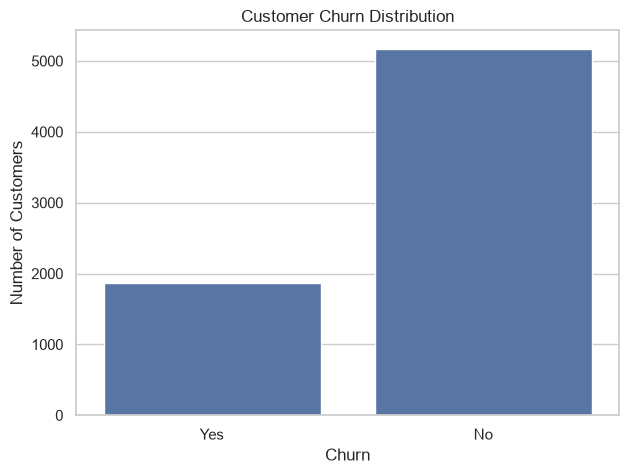

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,x="churn_label")

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

In [15]:
print(df.columns.tolist())

['customer_id', 'count', 'country', 'state', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn_label', 'churn_value', 'churn_score', 'cltv', 'churn_reason', 'age_group', 'monthly_spend_category', 'tenure_group', 'high_value_customer', 'cltv_segment', 'churn_risk', 'payment_mode', 'internet_category', 'service_count', 'engagement_score', 'customer_status', 'location', 'avg_revenue_per_month', 'coordinates', 'churn_reason_category', 'loyalty_level', 'customer_segment']


In [16]:
churn_percentage = (

    df["churn_label"]

    .value_counts(normalize=True)

    *100

)

print(churn_percentage.round(2))

churn_label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


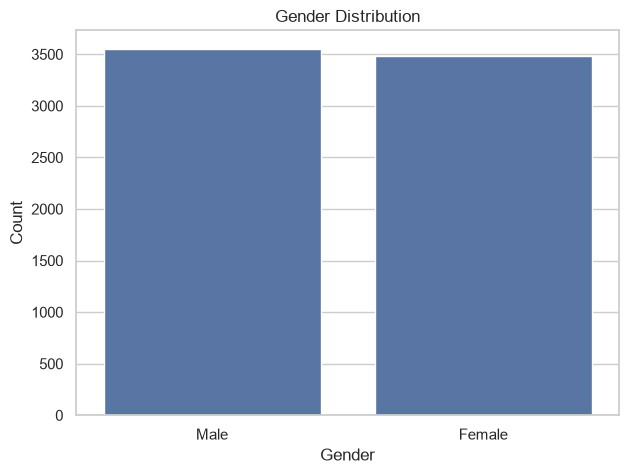

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="gender"

)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

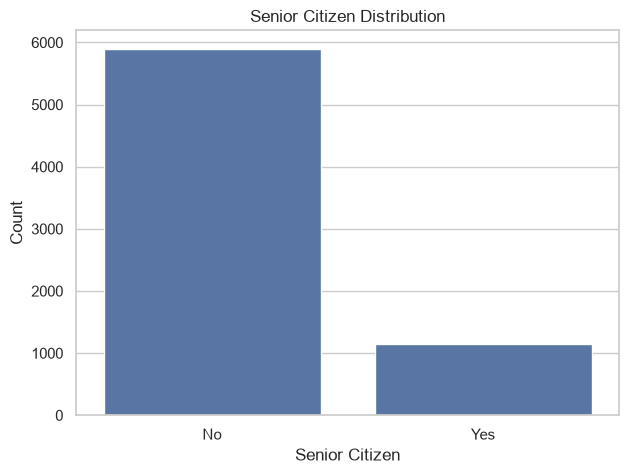

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="senior_citizen"

)

plt.title("Senior Citizen Distribution")

plt.xlabel("Senior Citizen")

plt.ylabel("Count")

plt.show()

# Contract Type Distribution

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\2209829365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


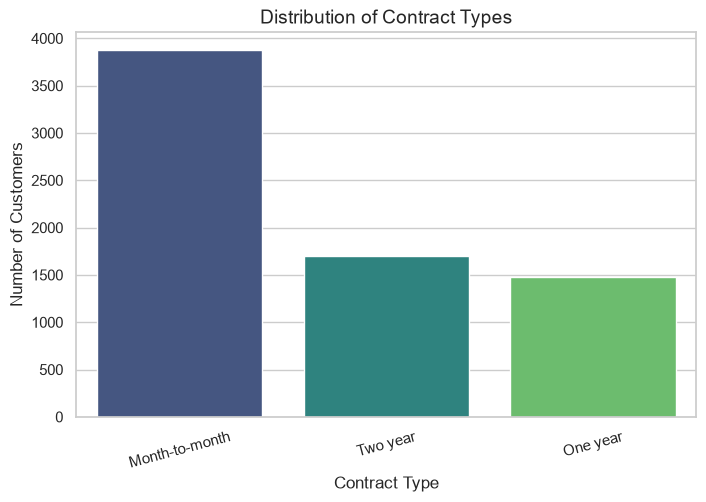

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="contract",
    order=df["contract"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Contract Types", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()